# Auditoría de observaciones compartidas

Construimos una única ley de emisión `p(X|r)` y la reutilizamos sin cambios en las dinámicas estática, cíclica e independiente. Cada fase produce una ventana con un template trasladado circularmente, amplitud y offset aleatorios, pequeño jitter temporal y ruido.

La comparación es pareada y deliberadamente estricta: las tres condiciones reutilizan exactamente los mismos bancos de ventanas actuales y futuras. Por lo tanto, ningún estadístico marginal de una ventana aislada puede revelar qué dinámica generó el par; sólo cambia el acoplamiento temporal entre ventanas.

Este notebook audita el dataset. El decoder nearest-template usa los templates verdaderos y funciona como oracle de observación, no como encoder aprendido.

In [1]:
# ruff: noqa: E402, E501
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Markdown, display
from sklearn.decomposition import PCA

from koopman_jepa.phase_data import (
    PhaseWindowConfig,
    make_shared_phase_observation_bundle,
    nearest_template_phase_predictions,
    ordered_observation_marginal,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
CONFIG_PATH = ROOT / "configs" / "observation_audit.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    raw_config = yaml.safe_load(handle)

config = PhaseWindowConfig(**raw_config["emission"])
seed = int(raw_config["seed"])
gates = raw_config["gates"]
bundle = make_shared_phase_observation_bundle(config, seed=seed)
DYNAMICS = ("static", "cyclic", "independent")
LABELS = {"static": "Estática", "cyclic": "Cíclica", "independent": "Independiente"}

print(json.dumps({"seed": seed, "emission": raw_config["emission"], "gates": gates}, indent=2))

{
  "seed": 20260921,
  "emission": {
    "num_phases": 4,
    "window_length": 128,
    "repeats_per_transition": 64,
    "noise_std": 0.08,
    "amplitude_low": 0.8,
    "amplitude_high": 1.2,
    "offset_std": 0.15,
    "max_shift": 4,
    "pulse_width": 0.055,
    "secondary_offset": 0.1875,
    "secondary_strength": 0.45
  },
  "gates": {
    "minimum_phase_accuracy": 0.99,
    "maximum_decoded_transition_error": 0.01,
    "require_exact_shared_marginals": true,
    "require_distinct_source_future_banks": true
  }
}


In [3]:
def empirical_transition_matrix(current_phases, future_phases, num_phases):
    counts = np.zeros((num_phases, num_phases), dtype=np.float64)
    np.add.at(counts, (current_phases, future_phases), 1.0)
    return counts / counts.sum(axis=1, keepdims=True)

expected_transitions = {
    "static": np.eye(config.num_phases),
    "cyclic": np.roll(np.eye(config.num_phases), 1, axis=1),
    "independent": np.full((config.num_phases, config.num_phases), 1.0 / config.num_phases),
}
reference = bundle.conditions["static"]
reference_current = ordered_observation_marginal(reference, "current")
reference_future = ordered_observation_marginal(reference, "future")
metrics = {}
for dynamics in DYNAMICS:
    condition = bundle.conditions[dynamics]
    ordered_current = ordered_observation_marginal(condition, "current")
    ordered_future = ordered_observation_marginal(condition, "future")
    current_predictions = nearest_template_phase_predictions(condition.current_windows, bundle.templates, config.max_shift)
    future_predictions = nearest_template_phase_predictions(condition.future_windows, bundle.templates, config.max_shift)
    decoded_transition = empirical_transition_matrix(current_predictions, future_predictions, config.num_phases)
    true_transition = empirical_transition_matrix(condition.current_phases, condition.future_phases, config.num_phases)
    metrics[dynamics] = {
        "sample_count": int(len(condition.current_phases)),
        "current_phase_accuracy": float(np.mean(current_predictions == condition.current_phases)),
        "future_phase_accuracy": float(np.mean(future_predictions == condition.future_phases)),
        "current_marginal_max_difference": float(np.max(np.abs(ordered_current - reference_current))),
        "future_marginal_max_difference": float(np.max(np.abs(ordered_future - reference_future))),
        "true_transition_max_error": float(np.max(np.abs(true_transition - expected_transitions[dynamics]))),
        "decoded_transition_max_error": float(np.max(np.abs(decoded_transition - expected_transitions[dynamics]))),
        "decoded_transition": decoded_transition,
    }

max_marginal_difference = max(
    max(result["current_marginal_max_difference"], result["future_marginal_max_difference"])
    for result in metrics.values()
)
minimum_phase_accuracy = min(
    min(result["current_phase_accuracy"], result["future_phase_accuracy"])
    for result in metrics.values()
)
maximum_decoded_transition_error = max(result["decoded_transition_max_error"] for result in metrics.values())
source_future_mean_absolute_difference = float(np.mean(np.abs(reference_current - reference_future)))
source_future_banks_are_distinct = not np.array_equal(reference_current, reference_future)

serializable_metrics = {
    dynamics: {key: value for key, value in result.items() if key != "decoded_transition"}
    for dynamics, result in metrics.items()
}
print(json.dumps(serializable_metrics, indent=2))

{
  "static": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  },
  "cyclic": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  },
  "independent": {
    "sample_count": 1024,
    "current_phase_accuracy": 1.0,
    "future_phase_accuracy": 1.0,
    "current_marginal_max_difference": 0.0,
    "future_marginal_max_difference": 0.0,
    "true_transition_max_error": 0.0,
    "decoded_transition_max_error": 0.0
  }
}


In [4]:
exact_marginals_pass = (
    max_marginal_difference == 0.0
    if gates["require_exact_shared_marginals"]
    else True
)
phase_accuracy_pass = minimum_phase_accuracy >= gates["minimum_phase_accuracy"]
transition_pass = maximum_decoded_transition_error <= gates["maximum_decoded_transition_error"]
distinct_banks_pass = (
    source_future_banks_are_distinct
    if gates["require_distinct_source_future_banks"]
    else True
)
observation_audit_passed = bool(
    exact_marginals_pass and phase_accuracy_pass and transition_pass and distinct_banks_pass
)
audit_gate = {
    "exact_shared_marginals": bool(exact_marginals_pass),
    "phase_identifiable": bool(phase_accuracy_pass),
    "decoded_temporal_laws": bool(transition_pass),
    "distinct_source_future_banks": bool(distinct_banks_pass),
    "observation_audit_passed": observation_audit_passed,
}
print(json.dumps(audit_gate, indent=2))
assert observation_audit_passed

{
  "exact_shared_marginals": true,
  "phase_identifiable": true,
  "decoded_temporal_laws": true,
  "distinct_source_future_banks": true,
  "observation_audit_passed": true
}


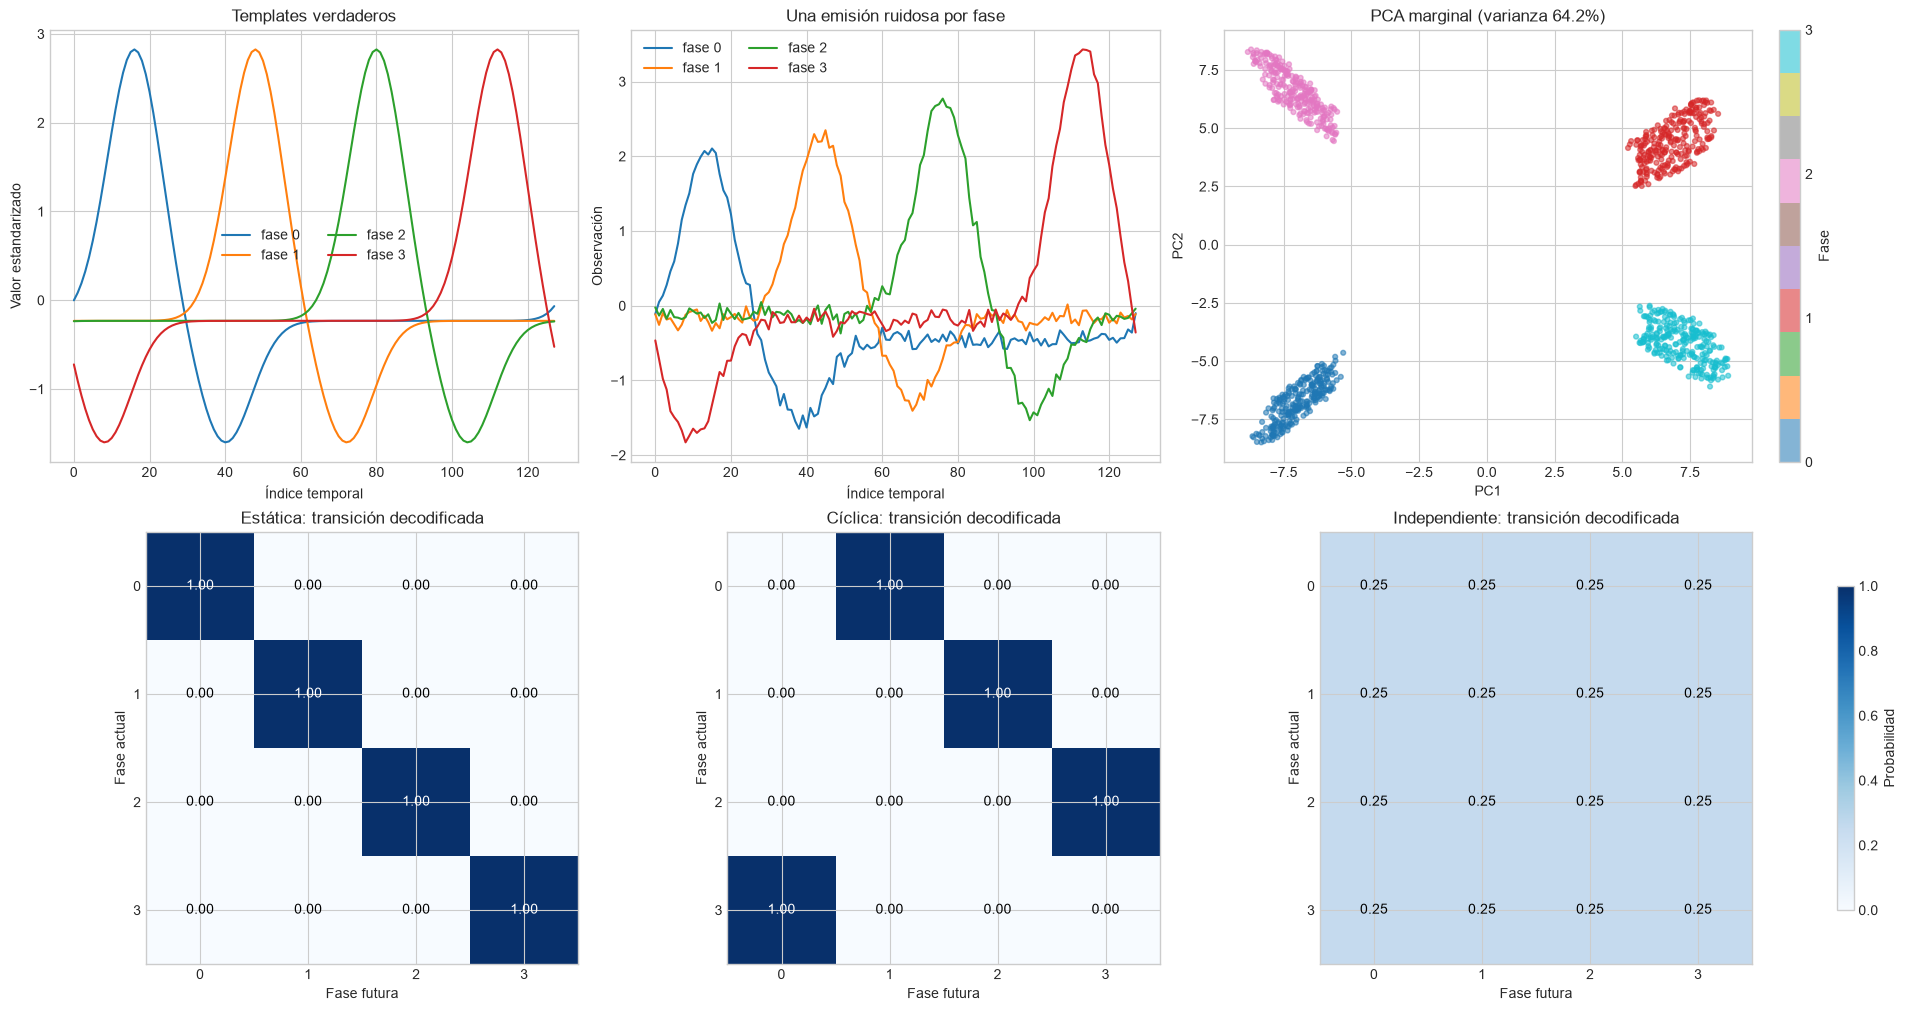

## Análisis del resultado

- Auditoría de datos: **PASS**.
- Pares por condición: **1024**; observaciones por fase y por marginal: **256**.
- Máxima diferencia entre marginales observables pareados: **0.00e+00**.
- Peor accuracy del decoder de fase oracle: **100.00%**.
- Máximo error de las transiciones decodificadas: **0.00e+00**.
- Diferencia absoluta media entre los bancos source y target: **0.341**.

Las tres condiciones contienen exactamente las mismas ventanas cuando se ordenan por fase e identificador de emisión. Por construcción, un clasificador que observa una sola ventana puede recuperar la fase, pero no puede saber si esa ventana pertenece a la condición estática, cíclica o independiente. Esa información sólo aparece al mirar el par temporal.

Las matrices inferiores recuperan las tres leyes después de decodificar las ventanas: identidad, avance cíclico y transición uniforme. Esto verifica que amplitud, offset, jitter y ruido no destruyen la señal de fase en esta primera dificultad.

La reutilización exacta de bancos es un control pareado intencional, no un supuesto sobre datos reales. Train, validation y test usarán seeds distintas para evitar compartir realizaciones. Este PASS valida el generador y habilita congelar el primer entrenamiento neuronal; todavía no demuestra que JEPA aprenda el subespacio de Koopman.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
time = np.arange(config.window_length)
for phase, template in enumerate(bundle.templates):
    axes[0, 0].plot(time, template, label=f"fase {phase}")
axes[0, 0].set(title="Templates verdaderos", xlabel="Índice temporal", ylabel="Valor estandarizado")
axes[0, 0].legend(ncol=2)

condition = bundle.conditions["independent"]
for phase in range(config.num_phases):
    index = int(np.flatnonzero(condition.current_phases == phase)[0])
    axes[0, 1].plot(time, condition.current_windows[index, 0], label=f"fase {phase}")
axes[0, 1].set(title="Una emisión ruidosa por fase", xlabel="Índice temporal", ylabel="Observación")
axes[0, 1].legend(ncol=2)

pca = PCA(n_components=2)
projection = pca.fit_transform(reference_current[:, 0, :])
ordered_phases = np.repeat(np.arange(config.num_phases), config.num_phases * config.repeats_per_transition)
scatter = axes[0, 2].scatter(projection[:, 0], projection[:, 1], c=ordered_phases, cmap="tab10", s=12, alpha=0.55)
axes[0, 2].set(title=f"PCA marginal (varianza {pca.explained_variance_ratio_.sum():.1%})", xlabel="PC1", ylabel="PC2")
fig.colorbar(scatter, ax=axes[0, 2], ticks=np.arange(config.num_phases), label="Fase")

for axis, dynamics in zip(axes[1], DYNAMICS, strict=True):
    image = axis.imshow(metrics[dynamics]["decoded_transition"], cmap="Blues", vmin=0, vmax=1)
    for row in range(config.num_phases):
        for column in range(config.num_phases):
            value = metrics[dynamics]["decoded_transition"][row, column]
            axis.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black")
    axis.set(title=f"{LABELS[dynamics]}: transición decodificada", xlabel="Fase futura", ylabel="Fase actual", xticks=range(config.num_phases), yticks=range(config.num_phases))
fig.colorbar(image, ax=axes[1].tolist(), shrink=0.75, label="Probabilidad")
plt.show()

display(Markdown(f"""## Análisis del resultado

- Auditoría de datos: **{'PASS' if observation_audit_passed else 'FAIL'}**.
- Pares por condición: **{metrics['static']['sample_count']}**; observaciones por fase y por marginal: **{config.num_phases * config.repeats_per_transition}**.
- Máxima diferencia entre marginales observables pareados: **{max_marginal_difference:.2e}**.
- Peor accuracy del decoder de fase oracle: **{minimum_phase_accuracy:.2%}**.
- Máximo error de las transiciones decodificadas: **{maximum_decoded_transition_error:.2e}**.
- Diferencia absoluta media entre los bancos source y target: **{source_future_mean_absolute_difference:.3f}**.

Las tres condiciones contienen exactamente las mismas ventanas cuando se ordenan por fase e identificador de emisión. Por construcción, un clasificador que observa una sola ventana puede recuperar la fase, pero no puede saber si esa ventana pertenece a la condición estática, cíclica o independiente. Esa información sólo aparece al mirar el par temporal.

Las matrices inferiores recuperan las tres leyes después de decodificar las ventanas: identidad, avance cíclico y transición uniforme. Esto verifica que amplitud, offset, jitter y ruido no destruyen la señal de fase en esta primera dificultad.

La reutilización exacta de bancos es un control pareado intencional, no un supuesto sobre datos reales. Train, validation y test usarán seeds distintas para evitar compartir realizaciones. Este PASS valida el generador y habilita congelar el primer entrenamiento neuronal; todavía no demuestra que JEPA aprenda el subespacio de Koopman.
"""))